In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

In [3]:
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

Found 900 images belonging to 3 classes.
Found 224 images belonging to 3 classes.


In [5]:
# CELL 5 — VGG16 Model Creation

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pre-trained VGG16
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze base layers
for layer in vgg_base.layers:
    layer.trainable = False

# Custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Final model
model = Model(inputs=vgg_base.input, outputs=output)

# Compile (same settings as other models)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [6]:
# CELL 6 — Train model

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    verbose=1
)

training_time = time.time() - start_time
training_time

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 660s 22s/step - accuracy: 0.3666 - loss: 1.2396 - val_accuracy: 0.4107 - val_loss: 1.0875
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 215ms/step - accuracy: 0.4010 - loss: 1.1547 - val_accuracy: 0.4196 - val_loss: 1.0795
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.4092 - loss: 1.0981 - val_accuracy: 0.4643 - val_loss: 1.0726
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.4640 - loss: 1.0414 - val_accuracy: 0.4286 - val_loss: 1.0658
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.5109 - loss: 0.9832 - val_accuracy: 0.4464 - val_loss: 1.0593
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.4755 - loss: 0.9928 - val_accuracy: 0.4330 - val_loss: 1.0621
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.5212 - loss: 0.9505 - val_accuracy: 0.5045 - val_loss: 1.0575
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.5477 - loss: 0.9367 - val_accuracy: 0.

1033.6368291378021

In [7]:
# CELL 7 — Predictions

y_true = val_data.classes
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step


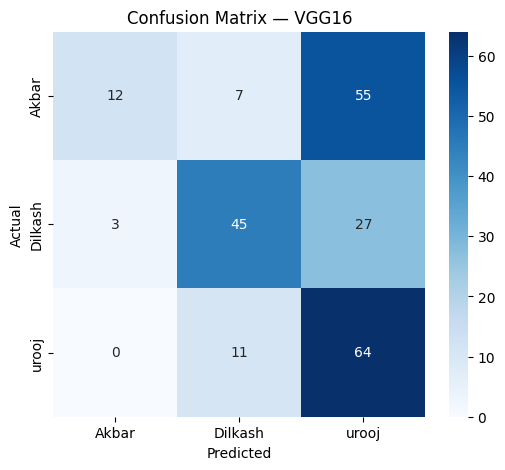

In [8]:
# CELL 8 — Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — VGG16")
plt.show()

In [9]:
# CELL 9 — Classification Report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

       Akbar     0.8000    0.1622    0.2697        74
     Dilkash     0.7143    0.6000    0.6522        75
       urooj     0.4384    0.8533    0.5792        75

    accuracy                         0.5402       224
   macro avg     0.6509    0.5385    0.5003       224
weighted avg     0.6502    0.5402    0.5014       224



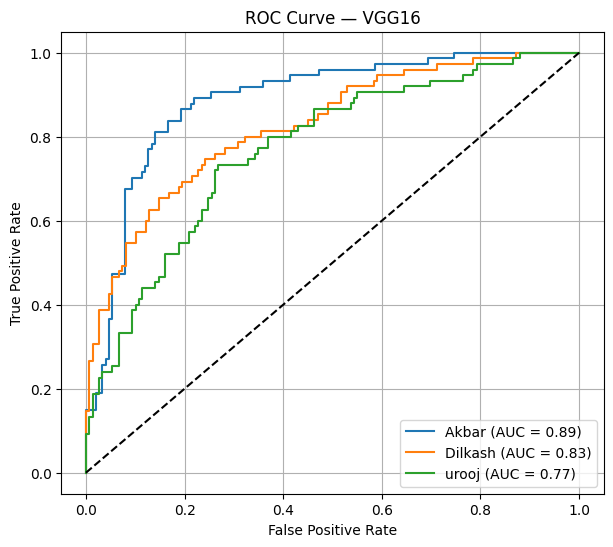

In [10]:
# CELL 10 — ROC & AUC

num_classes = NUM_CLASSES
y_true_bin = label_binarize(y_true, classes=range(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — VGG16")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# CELL 11 — Save evaluation results

val_loss, val_accuracy = model.evaluate(val_data, verbose=1)

# Extract weighted avg metrics
lines = report.split('\n')
weighted_avg = [l for l in lines if 'weighted avg' in l][0].split()

precision = float(weighted_avg[2])
recall = float(weighted_avg[3])
f1 = float(weighted_avg[4])

vgg_results = {
    "Model": "VGG16",
    "Accuracy": val_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "AUC (Avg)": np.mean(list(roc_auc.values())),
    "Training Time (sec)": training_time
}

vgg_results

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.3754 - loss: 1.2390


{'Model': 'VGG16',
 'Accuracy': 0.5401785969734192,
 'Precision': 0.6502,
 'Recall': 0.5402,
 'F1-score': 0.5014,
 'AUC (Avg)': np.float64(0.8273067698571054),
 'Training Time (sec)': 1033.6368291378021}

In [13]:
#12
import numpy as np
import pandas as pd
import os

SAVE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Task2_Results"
os.makedirs(SAVE_PATH, exist_ok=True)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = val_data.classes

# 1 = correct, 0 = wrong (needed for paired t-test)
correct_array = (y_pred_classes == y_true_classes).astype(int)

# CHANGE model name accordingly
MODEL_NAME = "vgg"   # change to "resnet" / "vgg"

np.save(f"{SAVE_PATH}/{MODEL_NAME}_correct.npy", correct_array)

# Save metrics
metrics_df = pd.DataFrame({
    "Accuracy": [val_accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [np.mean(list(roc_auc.values()))],
    "Training Time (sec)": [training_time]
})

metrics_df.to_csv(f"{SAVE_PATH}/{MODEL_NAME}_metrics.csv", index=False)

print("Saved results for", MODEL_NAME)


Saved results for vgg
